# **Ask Your Websites with Qdrant**

Authored by [Mohamed Arbi Nsibi](https://www.linkedin.com/in/mohammed-arbi-nsibi-584a43241/).

* Extract Web Page Content – Retrieve the raw text from the target web page.

* Split Text into Chunks – Divide the extracted text into smaller, manageable pieces.

* Create a Qdrant Vector Store – Store the text chunks as embeddings in a vector database.

* Initialize Retriever – Set up a retriever to fetch relevant chunks based on a user query.

* Build Context – Concatenate or format the retrieved chunks into a coherent context.

* Assemble RAG Chain – Combine the prompt template, LLM, and output parser to form the RAG pipeline.

* Query the RAG Chain – Run the chain with the user’s question to generate the answer.

## **Install and import libraries**


In [1]:
!pip install -qU langchain langchain-community langchain-text-splitters -q
!pip install -qU langchain-openai langchain-chroma -q
!pip install qdrant-client
!pip install langchain-qdrant -q

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters  import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda

## **Set up your OpenAI API Key**

- To enable your LLM in your environment:

- Save your API Key: Store your OPENAI_API_KEY securely in Google Colab Secrets.

- Go to Secrets on your right in Colab.

- Add a new secret with the name OPENAI_API_KEY and paste your key.

In [4]:
from google.colab import userdata
import os
OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')

## **Extract text from webpage**

In [138]:
from typing import List
from langchain.schema import Document

def webpage_to_text(page_url: List[str]) -> List[Document]:
    """
    purpose : extracts text from the web page using WebBaseLoader from document_loaders.

    input:
    page_url (str): The URL of the web page.

    output:
    List[Document]: A list of Document objects each containing the text content of a page.
    """

    print("Website page text is being extracted...")

    loader = WebBaseLoader(page_url)
    webpage_text = loader.load()
    return webpage_text

In [139]:
page_urls = ["https://qdrant.tech/documentation/quickstart/", "https://qdrant.tech/documentation/quickstart/",
             "https://qdrant.tech/documentation/fastembed/fastembed-semantic-search/","https://qdrant.tech/articles/what-is-vector-quantization/",
             "https://qdrant.tech/documentation/guides/multiple-partitions/"
]

webpage_texts = webpage_to_text(page_urls)

Website page text is being extracted...


In [140]:
print(webpage_texts)

[Document(metadata={'source': 'https://qdrant.tech/documentation/quickstart/', 'title': 'Local Quickstart - Qdrant', 'description': 'Qdrant is an Open-Source Vector Database and Vector Search Engine written in Rust. It provides fast and scalable vector similarity search service with convenient API.', 'language': 'en'}, page_content='Local Quickstart - Qdrant\nQdrantCloudBuildLearnAPI Reference\nSearch\nLog in\nStart Free\nSearch\nQdrant\nCloud\nBuild\nLearn\nAPI ReferenceGetting StartedWhat is Qdrant?Understanding Vector Search in QdrantLocal QuickstartAPI & SDKsQdrant Web UIUser ManualConceptsCollectionsPointsVectorsPayloadSearchExploreHybrid QueriesFilteringOptimizerStorageIndexingSnapshotsGuidesInstallationAdministrationRunning with GPUCapacity PlanningOptimize PerformanceMultitenancyDistributed DeploymentQuantizationMonitoring & TelemetryConfigurationSecurityUsage StatisticsTroubleshootingEcosystemFastEmbedQuickstartFastEmbed & QdrantWorking with miniCOILWorking with SPLADEWorking 

In [141]:
print(f"Number of documents = {len(webpage_texts)}")

Number of documents = 5


## **Split Texts into Chunks**

In [143]:
def chunking_text(webpage_text: List[Document]) -> List[Document]:
    """
    Split web page text into smaller chunks for embedding and retrieval.

    Parameters
    ----------
    webpage_text : List[Document]
        List of Documents containing extracted web page text.

    Returns
    -------
    List[Document]
        Chunked Documents with overlapping text to preserve context.
    Notes
    -----
    - `chunk_size` is set to 300 characters by default.
    - `chunk_overlap` is set to 50 characters by default.
    - Overlapping chunks improve embedding quality and context understanding.
    """

    print("Website text is being chunked....")

    text_splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=50)
    chunks = text_splitter.split_documents(webpage_text)

    return chunks

In [144]:
chunks = chunking_text(webpage_texts)

Website text is being chunked....


In [145]:
print(f"Number of chunks = {len(chunks)}")

Number of chunks = 398


In [146]:
print(chunks[0])

page_content='Local Quickstart - Qdrant
QdrantCloudBuildLearnAPI Reference
Search
Log in
Start Free
Search
Qdrant
Cloud
Build
Learn' metadata={'source': 'https://qdrant.tech/documentation/quickstart/', 'title': 'Local Quickstart - Qdrant', 'description': 'Qdrant is an Open-Source Vector Database and Vector Search Engine written in Rust. It provides fast and scalable vector similarity search service with convenient API.', 'language': 'en'}


In [12]:
# if you are using open source embedding model uncomment these two lines
# from langchain_community.embeddings import SentenceTransformerEmbeddings
# embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")

from langchain_openai import OpenAIEmbeddings
embedding_model = OpenAIEmbeddings(model="text-embedding-3-small", api_key = OPENAI_API_KEY)

In [127]:
len(embedding_model.embed_documents([chunk.page_content for chunk in chunks[:1]])[0]) # to see the length of the vector

1536

In [18]:
embed_size=len(embedding_model.embed_query("hello")) #embed_documents
embed_size

1536

## **Create our Super Qdrant Vector Store**

In [147]:
from qdrant_client import QdrantClient
from qdrant_client.models import VectorParams, Distance

# Initialize Qdrant client with persistent storage
client = QdrantClient(path="/content/my_pretty_qdrant_db")

# Create collection manually
collection_name = "website_docs"

try:
    client.get_collection(collection_name)
    print(f"Collection '{collection_name}' already exists.")
except:
    # if collection doesn't exist, create it
    client.create_collection(
        collection_name=collection_name,
        vectors_config=VectorParams(size=1536, distance=Distance.COSINE)
    )
    print(f"Created new collection: '{collection_name}'")

Created new collection: 'website_docs'


In [ ]:
# for an advanced stage using qdrant we can use this code but the current one is more than enough
# from langchain.schema import Document
# from qdrant_client import QdrantClient
# from qdrant_client.models import (
#     VectorParams, Distance, PointStruct,
#     OptimizersConfigDiff, QuantizationConfig,
#     BinaryQuantization, BinaryQuantizationConfig
# )
# from langchain_qdrant import QdrantVectorStore


# client = QdrantClient(path = "/content/db") #(":memory:")
# collection_name = "advanced_collection"


# client.create_collection(
#     collection_name=collection_name,
#     vectors_config=VectorParams(
#         size=embed_size,    #384 Dimension of all-MiniLM-L6-v2
#         distance=Distance.COSINE
#     ),
#     # Enable binary quantization for compression (as mentioned in your document)
#     quantization_config=BinaryQuantization(
#         binary=BinaryQuantizationConfig(
#             always_ram=True  # Keep quantized vectors in RAM for speed
#         )
#     ),
#     # Optimizer configuration
#     optimizers_config=OptimizersConfigDiff(
#         max_optimization_threads=2,
#         memmap_threshold=20000,
#         indexing_threshold=20000
#     )
# )

* what you should see on your right after you run this

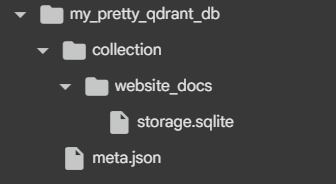

In [148]:
from qdrant_client.models import VectorParams, Distance, PointStruct

points = []
embeddings = embedding_model.embed_documents([chunk.page_content for chunk in chunks])
print("Embedding shape:", len(embeddings), len(embeddings[0]))

for i, chunk in enumerate(chunks):
    embedding = embeddings[i]

    # Create point
    point = PointStruct(
        id=i,
        vector=embedding,
        payload={
            "text": chunk.page_content,
            "source": chunk.metadata.get("source", ""),
            "title": chunk.metadata.get("title", ""),
            "description": chunk.metadata.get("description", ""),
            "language": chunk.metadata.get("language", "")
        }
    )
    points.append(point)

# Add to Qdrant
client.upsert(collection_name=collection_name, points=points)
print(f"✅ Added {len(points)} documents to Qdrant!")

Embedding shape: 398 1536
✅ Added 398 documents to Qdrant!


In [149]:
query = "how to set collection with docker?"
query= "how to make quantization with qdrant? "
query_vector = embedding_model.embed_query(query)

results = client.search(
    collection_name=collection_name,
    query_vector=query_vector,
    limit=5
)
for i, result in enumerate(results):
    print(f"\n--- Result {i+1} ---")
    print(f"Score: {result.score:.3f}")
    print(f"Source: {result.payload['source']}")
    print(f"Title: {result.payload['title']}")
    print(f"Content: {result.payload['text'][:200]}...")


--- Result 1 ---
Score: 0.714
Source: https://qdrant.tech/articles/what-is-vector-quantization/
Title: What is Vector Quantization? - Qdrant
Content: Switching Between Quantization MethodsNot sure if you‚Äôve chosen the right quantization method? In Qdrant, you have the flexibility to remove quantization and rely solely on the original vectors, adj...

--- Result 2 ---
Score: 0.692
Source: https://qdrant.tech/articles/what-is-vector-quantization/
Title: What is Vector Quantization? - Qdrant
Content: Quantized vs. Non-Quantized DataQdrant uses the quantized vectors by default if they are available. If you want to evaluate how quantization affects your search results, you can temporarily disable it...

--- Result 3 ---
Score: 0.679
Source: https://qdrant.tech/articles/what-is-vector-quantization/
Title: What is Vector Quantization? - Qdrant
Content: have a dedicated Quantization tips section in our docs that explains all the quantization tips you can use to enhance your results.Learn mo

## **Retrieve relevant chunks**

In [150]:
from typing import List
from langchain.schema import Document
from qdrant_client import QdrantClient

def search_documents(
    client: QdrantClient,
    query: str,
    collection_name: str = "website_docs",
    limit: int = 4
) -> List[Document]:
    """
    Search for similar documents in the Qdrant vector store.
    """
    # embed query
    query_vector = embedding_model.embed_query(query)

    # Search in Qdrant
    results = client.search(
        collection_name=collection_name,
        query_vector=query_vector,
        limit=limit
    )

    # Convert to Document objects
    documents = []
    for result in results:
        doc = Document(
            page_content=result.payload['text'],
            metadata={k: v for k, v in result.payload.items() if k != 'text'}
        )
        doc.metadata['similarity_score'] = result.score
        documents.append(doc)

    return documents


In [152]:
retrieved_docs = search_documents(client ," what is fastembed?","website_docs" , 5 )
for i, doc in enumerate(retrieved_docs):
    print(f"\n--- Result {i+1} ---")
    print(f"Score: {doc.metadata['similarity_score']:.3f}")
    print(f"Content: {doc.page_content[:700]}...")



--- Result 1 ---
Score: 0.525
Content: Qdrant Client and FastEmbedpip install "qdrant-client[fastembed]>=1.14.2"...

--- Result 2 ---
Score: 0.477
Content: Async APIMigration to QdrantStatic Embeddings. Should you pay attention?SupportFAQQdrant FundamentalsDatabase OptimizationRelease NotesDocumentationFastembedFastEmbed & QdrantUsing FastEmbed with Qdrant for Vector SearchInstall Qdrant Client and FastEmbedpip install...

--- Result 3 ---
Score: 0.378
Content: with FastEmbedQdrant MCP ServerTutorialsVector Search BasicsSemantic Search 101Build a Neural Search ServiceSetup Hybrid Search with FastEmbedMeasure Search QualityAdvanced RetrievalHow to Use Multivector Representations with Qdrant EffectivelyReranking in Hybrid SearchSearch Through Your...

--- Result 4 ---
Score: 0.378
Content: with FastEmbedQdrant MCP ServerTutorialsVector Search BasicsSemantic Search 101Build a Neural Search ServiceSetup Hybrid Search with FastEmbedMeasure Search QualityAdvanced RetrievalHow to Use Multive

## **Building our Context**

In [153]:
def build_context(relevant_chunks: List[Document]) -> str:
    """
    Builds a context string from retrieved relevant document chunks.

    Parameters:
    relevant_chunks (List[Document]): A list of retrieved relevant document chunks.

    Returns:
    str: A concatenated string containing the content of the relevant chunks.
    """

    print("Context is built from relevant chunks")
    context = "\n\n".join([chunk.page_content for chunk in relevant_chunks])

    return context

In [154]:
context = build_context(retrieved_docs)
context

Context is built from relevant chunks


'Qdrant Client and FastEmbedpip install "qdrant-client[fastembed]>=1.14.2"\n\nAsync APIMigration to QdrantStatic Embeddings. Should you pay attention?SupportFAQQdrant FundamentalsDatabase OptimizationRelease NotesDocumentationFastembedFastEmbed & QdrantUsing FastEmbed with Qdrant for Vector SearchInstall Qdrant Client and FastEmbedpip install\n\nwith FastEmbedQdrant MCP ServerTutorialsVector Search BasicsSemantic Search 101Build a Neural Search ServiceSetup Hybrid Search with FastEmbedMeasure Search QualityAdvanced RetrievalHow to Use Multivector Representations with Qdrant EffectivelyReranking in Hybrid SearchSearch Through Your\n\nwith FastEmbedQdrant MCP ServerTutorialsVector Search BasicsSemantic Search 101Build a Neural Search ServiceSetup Hybrid Search with FastEmbedMeasure Search QualityAdvanced RetrievalHow to Use Multivector Representations with Qdrant EffectivelyReranking in Hybrid SearchSearch Through Your\n\nwith FastEmbedQdrant MCP ServerTutorialsVector Search BasicsSemant

In [155]:
template = """ You are an AI model trained for question answering. You should answer the
  given question about qdrant documentation based on the given context only.
  Format your answer in **Markdown**.
- Use headings for sections
- Use numbered lists for steps
- Use triple backticks for code blocks with the correct language
  Question : {query}
  \n
  Context : {context}
  \n

  """
rag_prompt = ChatPromptTemplate.from_template(template)

## **Putting all together**

In [156]:
def build_response(
    client: QdrantClient,
    query: str,
    collection_name: str = "website_docs",
    k: int = 5
) -> str:
    """
    Retrieves relevant chunks from Qdrant, builds context,
    and generates an LLM response based on the query.
    """
    #Retrieve relevant docs
    relevant_chunks = search_documents(client, query, collection_name, k)

    print("\n------------Relevant Chunks------------")
    for i, doc in enumerate(relevant_chunks):
        print(f"\n--- Result {i+1} ---")
        print(f"Score: {doc.metadata['similarity_score']:.3f}")
        print(f"Content: {doc.page_content[:700]}...")

    # Build context string
    context = build_context(relevant_chunks)
    print("\n-------------Context-----------\n",
          context[:500], "...\n")

    # Format into prompt
    formatted_prompt = rag_prompt.format(context=context, query=query)
    #print("formatted_prompt:\n",formatted_prompt)

    llm = ChatOpenAI(model='gpt-4o-mini', api_key=OPENAI_API_KEY)
    response = llm.invoke(formatted_prompt)
    print("\n-------------Response-----------\n")
    return response.content


In [157]:
from IPython.display import Markdown, display
answer = build_response(client , "how to set qdrant with Docker?",k=5 )
display(Markdown(answer)) ## pretty cool right ? comment this to see the impact



------------Relevant Chunks------------

--- Result 1 ---
Score: 0.659
Content: On Windows, you may need to create a named Docker volume instead of mounting a local folder.Under the default configuration all data will be stored in the ./qdrant_storage directory. This will also be the only directory that both the Container and the host machine can both see.Qdrant is now...

--- Result 2 ---
Score: 0.659
Content: On Windows, you may need to create a named Docker volume instead of mounting a local folder.Under the default configuration all data will be stored in the ./qdrant_storage directory. This will also be the only directory that both the Container and the host machine can both see.Qdrant is now...

--- Result 3 ---
Score: 0.639
Content: Then, run the service:docker run -p 6333:6333 -p 6334:6334 \
    -v "$(pwd)/qdrant_storage:/qdrant/storage:z" \
    qdrant/qdrant...

--- Result 4 ---
Score: 0.639
Content: Then, run the service:docker run -p 6333:6333 -p 6334:6334 \
    -v "$(pwd)/

# Setting Up Qdrant with Docker

To set up Qdrant using Docker, follow these steps:

## Prerequisites
1. Make sure Docker is installed and running on your system.

## Steps to Set Up Qdrant

1. **Download the Latest Qdrant Image**
   Run the following command to pull the latest Qdrant Docker image from Docker Hub:
   ```bash
   docker pull qdrant/qdrant
   ```

2. **Create a Named Docker Volume (if on Windows)**
   Instead of mounting a local folder, create a named Docker volume for data storage. This is particularly important for Windows users.

3. **Run the Qdrant Service**
   Execute the following command to start the Qdrant service, which maps the necessary ports and sets up the storage directory:
   ```bash
   docker run -p 6333:6333 -p 6334:6334 \
       -v "$(pwd)/qdrant_storage:/qdrant/storage:z" \
       qdrant/qdrant
   ```

## Note
- By default, all data will be stored in the `./qdrant_storage` directory, which is accessible to both the Container and the host machine.

In [159]:
query= "how to configure Configure Multitenancy with qdrant?"
query = "how to make quantization with qdrant?"
answer = build_response(client , query,k=5 )
display(Markdown(answer))


------------Relevant Chunks------------

--- Result 1 ---
Score: 0.708
Content: Switching Between Quantization MethodsNot sure if you‚Äôve chosen the right quantization method? In Qdrant, you have the flexibility to remove quantization and rely solely on the original vectors, adjust the quantization type, or change compression parameters at any time without affecting your...

--- Result 2 ---
Score: 0.694
Content: Quantized vs. Non-Quantized DataQdrant uses the quantized vectors by default if they are available. If you want to evaluate how quantization affects your search results, you can temporarily disable it to compare results from quantized and non-quantized searches. To do this, set ignore: true in the...

--- Result 3 ---
Score: 0.672
Content: $$This leads to a 32x memory reduction.Qdrant automates the Binary Quantization process during indexing. As vectors are added to your collection, each 32-bit floating-point component is converted into a binary value according to the config

# How to Make Quantization with Qdrant

To implement quantization in Qdrant, follow these steps:

## Steps to Set Up Quantization

1. **Choose a Quantization Method**:
   - You can choose to remove quantization, adjust the quantization type, or change compression parameters without affecting your existing data.

2. **Set Up Scalar Quantization**:
   - When creating or updating a collection, include the `quantization_config` section in your request. 

   Here’s an example of how to set this up:

   ```http
   PUT /collections/{collection_name}
   {
     "quantization_config": {
       // Define your quantization parameters here
     }
   }
   ```

3. **Enable or Disable Quantization for Testing**:
   - If you want to evaluate the impact of quantization on your search results, you can temporarily disable it by setting the parameter `ignore: true` in your search request.

4. **Monitor Performance**:
   - After implementing quantization, monitor how it affects your search results and adjust your parameters as needed based on performance.

5. **Explore Additional Resources**:
   - Consult the dedicated Quantization tips section in the documentation for more insights and optimization techniques.

By following these steps, you can effectively implement and manage quantization in Qdrant, ensuring optimal performance and memory usage.